In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from datasets import load_dataset, Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

In [2]:
ds = load_dataset("Tobi-Bueck/customer-support-tickets")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
ds["train"][6]

{'subject': 'System Interruptions',
 'body': 'Dear Customer Support Team,\\n\\nI am submitting a report regarding multiple system service disruptions that are currently interfering with project operations and client interactions. These interruptions have notably reduced efficiency and caused delays in meeting important deadlines.\\n\\nInitial assessments suggest that the primary issue may be linked to widespread failures in network hardware connectivity. We have already carried out several basic troubleshooting procedures, such as rebooting devices and performing initial system checks, but the problems persist.',
 'answer': "Thank you for bringing the system disruptions to our attention. We understand the importance of maintaining stable services for project workflows and client communications, and we apologize for the inconvenience caused. To assist us in diagnosing the issue, could you please provide specific details about the affected systems or services, the approximate start time 

In [4]:
ds["train"].column_names

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [5]:
type(ds)

datasets.dataset_dict.DatasetDict

In [6]:
train_ds = ds["train"]

In [7]:
train_en_ds = train_ds.filter(lambda x: x["language"] == "en")

In [8]:
df = train_en_ds.to_pandas()

In [9]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None


In [10]:
df.shape

(28261, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28261 entries, 0 to 28260
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   24622 non-null  object 
 1   body      28260 non-null  object 
 2   answer    28255 non-null  object 
 3   type      28261 non-null  object 
 4   queue     28261 non-null  object 
 5   priority  28261 non-null  object 
 6   language  28261 non-null  object 
 7   version   16338 non-null  float64
 8   tag_1     28261 non-null  object 
 9   tag_2     28245 non-null  object 
 10  tag_3     28148 non-null  object 
 11  tag_4     25677 non-null  object 
 12  tag_5     16301 non-null  object 
 13  tag_6     7908 non-null   object 
 14  tag_7     3699 non-null   object 
 15  tag_8     1608 non-null   object 
dtypes: float64(1), object(15)
memory usage: 3.4+ MB


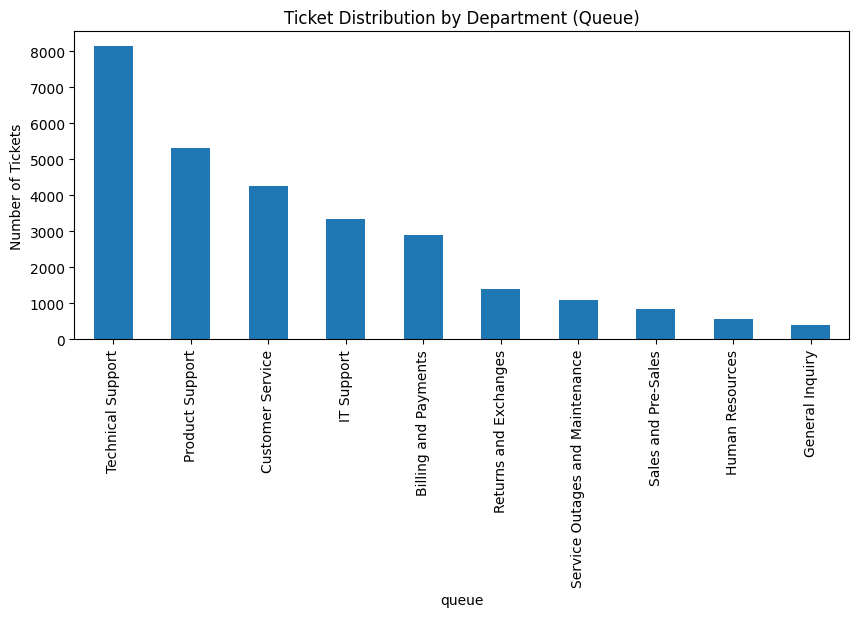

In [12]:
queue_counts = df["queue"].value_counts()

plt.figure(figsize=(10,4))
queue_counts.plot(kind="bar")
plt.title("Ticket Distribution by Department (Queue)")
plt.ylabel("Number of Tickets")
plt.show()

In [13]:
ds1 = pd.read_csv("/content/df_tickets_translated_en.csv")

Missing from ds1['queue']: []


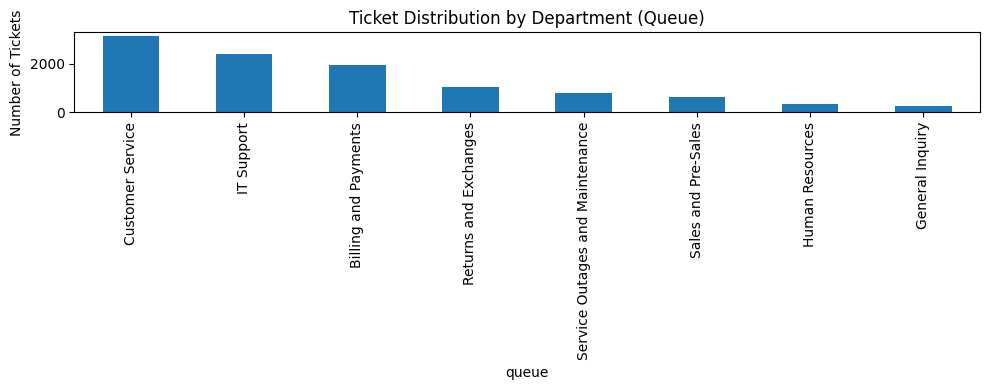

In [14]:
import matplotlib.pyplot as plt

# Queues visible in your screenshot
QUEUES_IN_IMAGE = [
    "Customer Service",
    "IT Support",
    "Billing and Payments",
    "Returns and Exchanges",
    "Service Outages and Maintenance",
    "Sales and Pre-Sales",
    "Human Resources",
    "General Inquiry",
]

# (Optional but precise) sanity check: see if any names don't match your CSV exactly
present = set(ds1["queue"].dropna().unique())
missing = [q for q in QUEUES_IN_IMAGE if q not in present]
print("Missing from ds1['queue']:", missing)

# Filter to only those queues, then count and plot (ordered like the list above)
queue_counts = (
    ds1.loc[ds1["queue"].isin(QUEUES_IN_IMAGE), "queue"]
      .value_counts()
      .reindex(QUEUES_IN_IMAGE)
      .dropna()
)

plt.figure(figsize=(10, 4))
queue_counts.plot(kind="bar")
plt.title("Ticket Distribution by Department (Queue)")
plt.ylabel("Number of Tickets")
plt.xlabel("queue")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

QUEUES_IN_IMAGE = [
    "Customer Service",
    "IT Support",
    "Billing and Payments",
    "Returns and Exchanges",
    "Service Outages and Maintenance",
    "Sales and Pre-Sales",
    "Human Resources",
    "General Inquiry",
]

ds1 = pd.read_csv("df_tickets_translated_en.csv")

# keep only those departments from ds1
ds1_sel = ds1[ds1["queue"].isin(QUEUES_IN_IMAGE)].copy()

# append to df (row-wise)
df = pd.concat([df, ds1_sel], ignore_index=True)

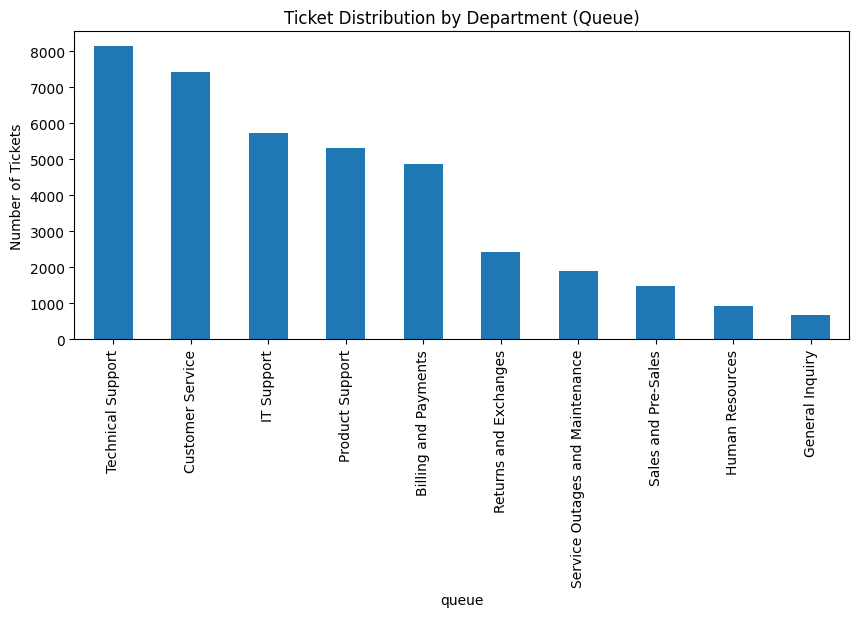

In [16]:
queue_counts = df["queue"].value_counts()

plt.figure(figsize=(10,4))
queue_counts.plot(kind="bar")
plt.title("Ticket Distribution by Department (Queue)")
plt.ylabel("Number of Tickets")
plt.show()

In [17]:
df["text"] = (
    df["subject"].fillna("") + " " + df["body"].fillna("")
)

In [18]:
df[["subject", "body", "text"]].head(3)

,subject,body,text
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,..."
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...


In [19]:
df["language"].value_counts()

,count
language,
en,38895


In [20]:
df = df[["text", "queue", "priority"]]
df.head()

,text,queue,priority
0,"Account Disruption Dear Customer Support Team,...",Technical Support,high
1,Query About Smart Home System Integration Feat...,Returns and Exchanges,medium
2,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,low
3,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,medium
4,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,high


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

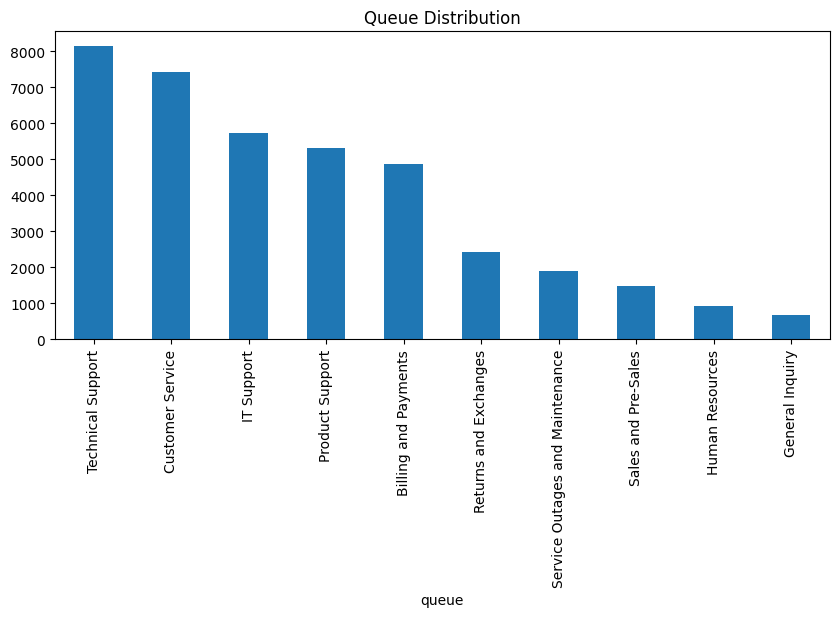

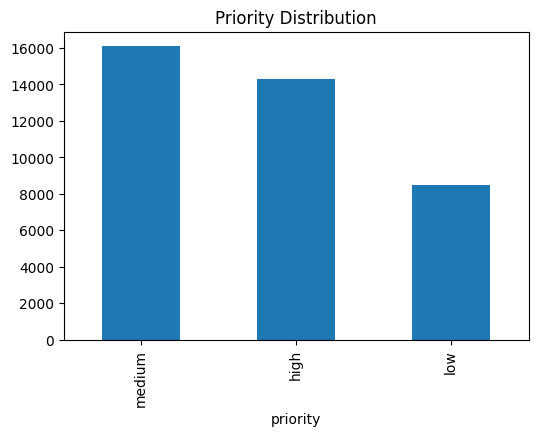

In [22]:
plt.figure(figsize=(10,4))
df["queue"].value_counts().plot(kind="bar")
plt.title("Queue Distribution")
plt.show()

plt.figure(figsize=(6,4))
df["priority"].value_counts().plot(kind="bar")
plt.title("Priority Distribution")
plt.show()

In [23]:
df["text_len"] = df["text"].str.split().str.len()

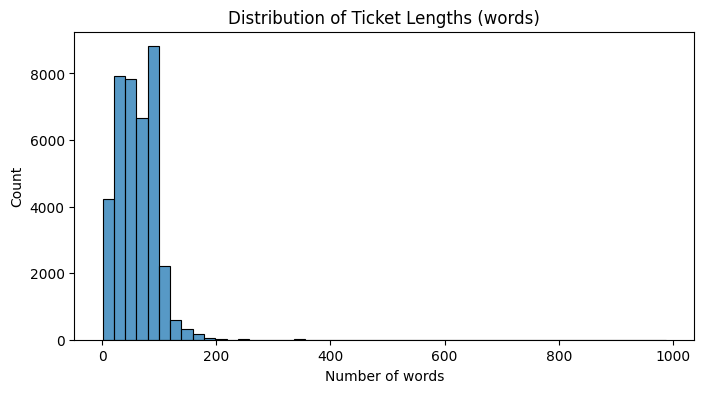

In [24]:
plt.figure(figsize=(8,4))
sns.histplot(df["text_len"], bins=50)
plt.title("Distribution of Ticket Lengths (words)")
plt.xlabel("Number of words")
plt.show()

In [25]:
df.isnull().sum().sort_values(ascending=False)

,0
text,0
queue,0
priority,0
text_len,0


In [26]:
(df["text"].str.strip() == "").sum()

np.int64(0)

In [27]:
df["queue"].unique()

array(['Technical Support', 'Returns and Exchanges',
       'Billing and Payments', 'Sales and Pre-Sales',
       'Service Outages and Maintenance', 'Product Support', 'IT Support',
       'Customer Service', 'Human Resources', 'General Inquiry'],
      dtype=object)

In [28]:
df["priority"].unique()

array(['high', 'medium', 'low'], dtype=object)

In [29]:
label_summary = pd.DataFrame({
    "queue_count": df["queue"].value_counts(),
    "priority_count": df["priority"].value_counts()
})

In [30]:
label_summary

,queue_count,priority_count
Billing and Payments,4874.0,NaN
Customer Service,7420.0,NaN
General Inquiry,668.0,NaN
Human Resources,914.0,NaN
IT Support,5725.0,NaN
Product Support,5305.0,NaN
Returns and Exchanges,2438.0,NaN
Sales and Pre-Sales,1490.0,NaN
Service Outages and Maintenance,1912.0,NaN
Technical Support,8149.0,NaN


In [31]:
from sklearn.preprocessing import LabelEncoder

queue_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

df["queue_id"] = queue_encoder.fit_transform(df["queue"])
df["priority_id"] = priority_encoder.fit_transform(df["priority"])

df.head()

,text,queue,priority,text_len,queue_id,priority_id
0,"Account Disruption Dear Customer Support Team,...",Technical Support,high,84,9,0
1,Query About Smart Home System Integration Feat...,Returns and Exchanges,medium,83,6,2
2,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,low,95,0,1
3,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,medium,103,7,2
4,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,high,99,9,0


In [32]:
from datasets import Dataset

hf_dataset = Dataset.from_pandas(df[["text", "queue_id", "priority_id"]])

dataset = hf_dataset.train_test_split(test_size=0.3, seed=42)

temp_split = dataset["test"].train_test_split(test_size=0.5, seed=42)

dataset = {
    "train": dataset["train"],
    "validation": temp_split["train"],
    "test": temp_split["test"]
}

dataset

{'train': Dataset({
     features: ['text', 'queue_id', 'priority_id'],
     num_rows: 27226
 }),
 'validation': Dataset({
     features: ['text', 'queue_id', 'priority_id'],
     num_rows: 5834
 }),
 'test': Dataset({
     features: ['text', 'queue_id', 'priority_id'],
     num_rows: 5835
 })}

In [33]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

for split in dataset:
    dataset[split] = dataset[split].map(tokenize, batched=True)

for split in dataset:
    dataset[split].set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "queue_id", "priority_id"]
    )

Map:   0%|          | 0/27226 [00:00<?, ? examples/s]

Map:   0%|          | 0/5834 [00:00<?, ? examples/s]

Map:   0%|          | 0/5835 [00:00<?, ? examples/s]

In [34]:
from datasets import DatasetDict

queue_dataset = DatasetDict({
    "train": dataset["train"].rename_column("queue_id", "labels"),
    "validation": dataset["validation"].rename_column("queue_id", "labels"),
    "test": dataset["test"].rename_column("queue_id", "labels")
}).remove_columns(["priority_id"])

priority_dataset = DatasetDict({
    "train": dataset["train"].rename_column("priority_id", "labels"),
    "validation": dataset["validation"].rename_column("priority_id", "labels"),
    "test": dataset["test"].rename_column("priority_id", "labels")
}).remove_columns(["queue_id"])

In [35]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

In [36]:
queue_model_v1 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(queue_encoder.classes_)
)

priority_model_v1 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(priority_encoder.classes_)
)

training_args_v1 = TrainingArguments(
    output_dir="./baseline",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"
)

queue_trainer_v1 = Trainer(
    model=queue_model_v1,
    args=training_args_v1,
    train_dataset=queue_dataset["train"],
    eval_dataset=queue_dataset["validation"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

priority_trainer_v1 = Trainer(
    model=priority_model_v1,
    args=training_args_v1,
    train_dataset=priority_dataset["train"],
    eval_dataset=priority_dataset["validation"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

queue_trainer_v1.train()
priority_trainer_v1.train()

metrics_queue_v1 = queue_trainer_v1.evaluate(queue_dataset["test"])
metrics_priority_v1 = priority_trainer_v1.evaluate(priority_dataset["test"])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.589518,1.522645,0.449606,0.349387,0.422911
2,1.298883,1.338388,0.535139,0.465870,0.523852
3,0.922938,1.249934,0.589990,0.534667,0.583304


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.996787,0.984943,0.505314,0.420314,0.466212
2,0.874029,0.907038,0.584847,0.543472,0.569841
3,0.638711,0.872155,0.635756,0.614531,0.631273


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [37]:
from sklearn.utils.class_weight import compute_class_weight
import torch

queue_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["queue_id"]),
    y=df["queue_id"]
)

priority_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["priority_id"]),
    y=df["priority_id"]
)

queue_weights = torch.tensor(queue_weights, dtype=torch.float)
priority_weights = torch.tensor(priority_weights, dtype=torch.float)

In [38]:
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False,
                     num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(model.device)
        )

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [39]:
queue_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(queue_encoder.classes_)
)

priority_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(priority_encoder.classes_)
)

training_args_v2 = TrainingArguments(
    output_dir="./weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1"
)

queue_trainer_v2 = WeightedTrainer(
    model=queue_model_v2,
    args=training_args_v2,
    train_dataset=queue_dataset["train"],
    eval_dataset=queue_dataset["validation"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    class_weights=queue_weights
)

priority_trainer_v2 = WeightedTrainer(
    model=priority_model_v2,
    args=training_args_v2,
    train_dataset=priority_dataset["train"],
    eval_dataset=priority_dataset["validation"],
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    class_weights=priority_weights
)

queue_trainer_v2.train()
priority_trainer_v2.train()

metrics_queue_v2_before = queue_trainer_v2.evaluate(queue_dataset["test"])
metrics_priority_v2_before = priority_trainer_v2.evaluate(priority_dataset["test"])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.767446,1.702441,0.397326,0.370538,0.389047
2,1.417612,1.415107,0.475831,0.487622,0.471794
3,0.963016,1.324111,0.521426,0.532246,0.518955


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.017460,0.992016,0.446349,0.410514,0.393734
2,0.848068,0.908718,0.585533,0.579302,0.582026
3,0.598812,0.883707,0.642612,0.639383,0.642477


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [40]:
def extract_metrics(name, metrics):
    return {
        "Model": name,
        "Accuracy": metrics["eval_accuracy"],
        "Macro_F1": metrics["eval_macro_f1"],
        "Weighted_F1": metrics["eval_weighted_f1"]
    }

comparison_queue = pd.DataFrame([
    extract_metrics("Queue_v1", metrics_queue_v1),
    extract_metrics("Queue_v2_Weighted", metrics_queue_v2_before)
])

comparison_priority = pd.DataFrame([
    extract_metrics("Priority_v1", metrics_priority_v1),
    extract_metrics("Priority_v2_Weighted", metrics_priority_v2_before)
])

comparison_priority

,Model,Accuracy,Macro_F1,Weighted_F1
0,Priority_v1,0.647301,0.632487,0.645089
1,Priority_v2_Weighted,0.636504,0.637227,0.636850


In [41]:
comparison_queue

,Model,Accuracy,Macro_F1,Weighted_F1
0,Queue_v1,0.610626,0.550397,0.604582
1,Queue_v2_Weighted,0.529392,0.528424,0.525961


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
queue_model_v1.to(device)
priority_model_v1.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [43]:
def predict_queue(text):
    queue_model_v1.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(queue_model_v1.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = queue_model_v1(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
    return queue_encoder.inverse_transform([pred_id])[0], probs.max().item()

def predict_priority(text):
    priority_model_v1.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(priority_model_v1.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = priority_model_v1(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()
    return priority_encoder.inverse_transform([pred_id])[0], probs.max().item()

In [44]:
queue_feedback_memory = []
priority_feedback_memory = []

In [45]:
def active_learning_step(text, threshold=0.85):

    print("\n" + "="*70)
    print("TICKET:\n", text)
    print("="*70)

    q_label, q_conf = predict_queue(text)
    print("\nQueue:", q_label, "| Confidence:", round(q_conf,3))

    if q_conf < threshold:
        for i, label in enumerate(queue_encoder.classes_):
            print(f"{i} → {label}")
        selected = int(input("Correct queue label number: "))
        queue_feedback_memory.append({
            "text": text,
            "queue_id": queue_encoder.transform([queue_encoder.classes_[selected]])[0]
        })

    p_label, p_conf = predict_priority(text)
    print("\nPriority:", p_label, "| Confidence:", round(p_conf,3))

    if p_conf < threshold:
        for i, label in enumerate(priority_encoder.classes_):
            print(f"{i} → {label}")
        selected = int(input("Correct priority label number: "))
        priority_feedback_memory.append({
            "text": text,
            "priority_id": priority_encoder.transform([priority_encoder.classes_[selected]])[0]
        })

In [46]:
from datasets import concatenate_datasets

In [47]:
def retrain_queue_from_feedback():
    global queue_dataset, queue_trainer_v1

    if len(queue_feedback_memory) == 0:
        print("No queue feedback.")
        return

    print("Preparing queue feedback dataset...")

    feedback_df = pd.DataFrame(queue_feedback_memory)
    feedback_dataset = Dataset.from_pandas(feedback_df)

    feedback_dataset = feedback_dataset.map(tokenize, batched=True)
    feedback_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "queue_id"]
    )
    original_train = queue_dataset["train"].rename_column("labels", "queue_id")
    combined = concatenate_datasets([original_train, feedback_dataset])
    combined = combined.rename_column("queue_id", "labels")

    queue_dataset["train"] = combined
    queue_trainer_v1.train_dataset = queue_dataset["train"]

    print("Retraining queue model on updated dataset...")
    queue_trainer_v1.train()

    queue_feedback_memory.clear()
    print("Queue model updated permanently.")

In [48]:
def retrain_priority_from_feedback():
    global priority_dataset, priority_trainer_v1

    if len(priority_feedback_memory) == 0:
        print("No priority feedback.")
        return

    print("Preparing priority feedback dataset...")

    feedback_df = pd.DataFrame(priority_feedback_memory)
    feedback_dataset = Dataset.from_pandas(feedback_df)

    feedback_dataset = feedback_dataset.map(tokenize, batched=True)
    feedback_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "priority_id"]
    )

    original_train = priority_dataset["train"].rename_column("labels", "priority_id")

    combined = concatenate_datasets([original_train, feedback_dataset])
    combined = combined.rename_column("priority_id", "labels")
    priority_dataset["train"] = combined

    priority_trainer_v1.train_dataset = priority_dataset["train"]

    print("Retraining priority model on updated dataset...")
    priority_trainer_v1.train()

    priority_feedback_memory.clear()
    print("Priority model updated permanently.")

In [49]:
ticket_texts = [
"Dear Customer Support Team,\n\nI am writing to report that my most recent billing statement shows two identical charges for the same subscription renewal period. I have verified my payment history and can confirm that I only authorized a single renewal transaction.\n\nCould you please investigate this issue and provide clarification regarding the duplicate charge? I would also appreciate information on when I can expect the excess amount to be refunded.",

"Dear Customer Support Team,\n\nI am currently experiencing repeated system crashes whenever I attempt to upload required documentation through the mobile application. The application closes unexpectedly without displaying any error notification.\n\nI have already reinstalled the app and restarted my device multiple times, but the issue continues to persist. This problem is affecting my workflow and requires urgent technical assistance.",

"Dear Customer Support Team,\n\nFollowing a recent password reset request, I am no longer able to log into my account. The system consistently displays an 'invalid credentials' message, even though I am entering the updated password correctly.\n\nKindly advise on how this access issue can be resolved at the earliest convenience, as I require immediate access to my account settings.",

"Dear Customer Support Team,\n\nI am submitting a complaint regarding an order that has been marked as delivered in the tracking system. However, I have not received the package at my registered shipping address.\n\nPlease investigate this discrepancy and inform me of the appropriate next steps, including whether a replacement shipment or refund will be issued.",

"Dear Customer Support Team,\n\nI would like to suggest the introduction of a dark mode feature within the platform interface. The current design, particularly during extended evening usage, places considerable strain on the eyes.\n\nCould you please confirm whether this feature is under consideration for an upcoming update?",

"Dear Customer Support Team,\n\nI am seeking clarification regarding the features and benefits included in the premium subscription plan. The current documentation does not clearly outline the distinctions between the standard and premium tiers.\n\nKindly provide a detailed breakdown of the premium plan offerings so that I may evaluate whether an upgrade would be suitable for my requirements.",

"Dear Customer Support Team,\n\nMy payment attempt for this month’s subscription renewal failed, and as a result, my service access has been temporarily suspended. I have already verified that sufficient funds are available in my account.\n\nPlease investigate the cause of the payment failure and restore service access as soon as possible."
]

In [50]:
for text in ticket_texts:
    active_learning_step(text, threshold=0.85)


TICKET:
 Dear Customer Support Team,

I am writing to report that my most recent billing statement shows two identical charges for the same subscription renewal period. I have verified my payment history and can confirm that I only authorized a single renewal transaction.

Could you please investigate this issue and provide clarification regarding the duplicate charge? I would also appreciate information on when I can expect the excess amount to be refunded.

Queue: Billing and Payments | Confidence: 0.998

Priority: medium | Confidence: 0.713
0 → high
1 → low
2 → medium
Correct priority label number: 2

TICKET:
 Dear Customer Support Team,

I am currently experiencing repeated system crashes whenever I attempt to upload required documentation through the mobile application. The application closes unexpectedly without displaying any error notification.

I have already reinstalled the app and restarted my device multiple times, but the issue continues to persist. This problem is affect

In [51]:
print("Evaluating BEFORE active learning retrain...\n")

metrics_queue_v1_before = queue_trainer_v1.evaluate(queue_dataset["test"])
metrics_priority_v1_before = priority_trainer_v1.evaluate(priority_dataset["test"])

metrics_queue_v1_before, metrics_priority_v1_before

Evaluating BEFORE active learning retrain...



({'eval_loss': 1.19083571434021,
  'eval_accuracy': 0.6106255355612682,
  'eval_macro_f1': 0.5503974848403785,
  'eval_weighted_f1': 0.6045822485742921,
  'eval_runtime': 26.6405,
  'eval_samples_per_second': 219.027,
  'eval_steps_per_second': 13.701,
  'epoch': 3.0},
 {'eval_loss': 0.8506441712379456,
  'eval_accuracy': 0.6473007712082263,
  'eval_macro_f1': 0.6324871166620315,
  'eval_weighted_f1': 0.6450893890694964,
  'eval_runtime': 26.4554,
  'eval_samples_per_second': 220.56,
  'eval_steps_per_second': 13.797,
  'epoch': 3.0})

In [52]:
print("Retraining models with human feedback...\n")

retrain_queue_from_feedback()
retrain_priority_from_feedback()

Retraining models with human feedback...

Preparing queue feedback dataset...


Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Retraining queue model on updated dataset...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.980699,1.172335,0.614158,0.574528,0.609480
2,0.587284,1.155527,0.662667,0.638957,0.659243
3,0.309488,1.180698,0.697806,0.681245,0.697291


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Priority model updated permanently.


In [53]:
print("Evaluating AFTER active learning retrain...\n")

metrics_queue_v1_after = queue_trainer_v1.evaluate(queue_dataset["test"])
metrics_priority_v1_after = priority_trainer_v1.evaluate(priority_dataset["test"])

metrics_queue_v1_after, metrics_priority_v1_after

Evaluating AFTER active learning retrain...



({'eval_loss': 1.1451659202575684,
  'eval_accuracy': 0.7050556983718937,
  'eval_macro_f1': 0.6678221620994258,
  'eval_weighted_f1': 0.7042419898500824,
  'eval_runtime': 25.8835,
  'eval_samples_per_second': 225.433,
  'eval_steps_per_second': 14.102,
  'epoch': 3.0},
 {'eval_loss': 0.9986451864242554,
  'eval_accuracy': 0.7242502142245073,
  'eval_macro_f1': 0.7170496729589736,
  'eval_weighted_f1': 0.723779941120746,
  'eval_runtime': 26.4315,
  'eval_samples_per_second': 220.759,
  'eval_steps_per_second': 13.809,
  'epoch': 3.0})

In [54]:
final_comparison_queue = pd.DataFrame([
    extract_metrics("Queue_v1", metrics_queue_v1),
    extract_metrics("Queue_v1_After_AL", metrics_queue_v1_after)
])

final_comparison_priority = pd.DataFrame([
    extract_metrics("Priority_v1", metrics_priority_v1),
    extract_metrics("Priority_v1_After_AL", metrics_priority_v1_after)
])

print("QUEUE COMPARISON")
display(final_comparison_queue)

print("PRIORITY COMPARISON")
display(final_comparison_priority)

QUEUE COMPARISON


,Model,Accuracy,Macro_F1,Weighted_F1
0,Queue_v1,0.610626,0.550397,0.604582
1,Queue_v1_After_AL,0.705056,0.667822,0.704242


PRIORITY COMPARISON


,Model,Accuracy,Macro_F1,Weighted_F1
0,Priority_v1,0.647301,0.632487,0.645089
1,Priority_v1_After_AL,0.724250,0.717050,0.723780


In [57]:
# os.makedirs("./models", exist_ok=True)

# queue_trainer_v1.save_model("./models/queue_v1")
# priority_trainer_v1.save_model("./models/priority_v1")

# queue_trainer_v2.save_model("./models/queue_v2")
# priority_trainer_v2.save_model("./models/priority_v2")

# tokenizer.save_pretrained("./models/tokenizer")

from google.colab import drive
import os

drive.mount("/content/drive")

MODEL_DIR = "/content/drive/MyDrive/ML_SYS_DEP/V2"
os.makedirs(MODEL_DIR, exist_ok=True)

queue_trainer_v1.save_model(f"{MODEL_DIR}/queue_v1")
priority_trainer_v1.save_model(f"{MODEL_DIR}/priority_v1")

queue_trainer_v2.save_model(f"{MODEL_DIR}/queue_v2")
priority_trainer_v2.save_model(f"{MODEL_DIR}/priority_v2")

tokenizer.save_pretrained(f"{MODEL_DIR}/tokenizer")


Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/ML_SYS_DEP/V2/tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/ML_SYS_DEP/V2/tokenizer/tokenizer.json')

In [58]:
# joblib.dump(queue_encoder, "./models/queue_encoder.pkl")
# joblib.dump(priority_encoder, "./models/priority_encoder.pkl")

# print("All models and artifacts saved successfully.")

import joblib
MODEL_DIR = "/content/drive/MyDrive/ML_SYS_DEP/V2"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(queue_encoder, f"{MODEL_DIR}/queue_encoder.pkl")
joblib.dump(priority_encoder, f"{MODEL_DIR}/priority_encoder.pkl")

print("All models and artifacts saved to Google Drive.")


All models and artifacts saved to Google Drive.


In [59]:
import joblib

In [60]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# tokenizer = AutoTokenizer.from_pretrained("./models/tokenizer")

# queue_model = AutoModelForSequenceClassification.from_pretrained(
#     "./models/queue_v1"
# ).to(device)

# priority_model = AutoModelForSequenceClassification.from_pretrained(
#     "./models/priority_v1"
# ).to(device)

# # Load encoders
# queue_encoder = joblib.load("./models/queue_encoder.pkl")
# priority_encoder = joblib.load("./models/priority_encoder.pkl")

# print("Models and encoders loaded successfully.")

MODEL_DIR = "/content/drive/MyDrive/ML_SYS_DEP/V2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(f"{MODEL_DIR}/tokenizer")

queue_model = AutoModelForSequenceClassification.from_pretrained(
    f"{MODEL_DIR}/queue_v1"
).to(device)

priority_model = AutoModelForSequenceClassification.from_pretrained(
    f"{MODEL_DIR}/priority_v1"
).to(device)

queue_encoder = joblib.load(f"{MODEL_DIR}/queue_encoder.pkl")
priority_encoder = joblib.load(f"{MODEL_DIR}/priority_encoder.pkl")

print("Models and encoders loaded successfully.")



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Models and encoders loaded successfully.


In [61]:
def predict_queue(text):
    queue_model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = queue_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()

    label = queue_encoder.inverse_transform([pred_id])[0]
    confidence = probs.max().item()

    return label, confidence


def predict_priority(text):
    priority_model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = priority_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_id = probs.argmax(dim=1).item()

    label = priority_encoder.inverse_transform([pred_id])[0]
    confidence = probs.max().item()

    return label, confidence

In [62]:
text = "Dear Customer Support Team,\n\nMy payment attempt failed and my account has been suspended. Please resolve this urgently."

queue_label, queue_conf = predict_queue(text)
priority_label, priority_conf = predict_priority(text)

print("\nPrediction Results")
print("-" * 40)
print("Queue:", queue_label, "| Confidence:", round(queue_conf, 3))
print("Priority:", priority_label, "| Confidence:", round(priority_conf, 3))


Prediction Results
----------------------------------------
Queue: Billing and Payments | Confidence: 0.999
Priority: high | Confidence: 0.823


In [63]:
text = "Dear Customer Support Team,\n\nOur company is currently evaluating several software vendors for a long-term partnership. Before proceeding further, we would like to request a formal quotation outlining the pricing structure for bulk user licenses.\n\nCould you also confirm whether custom contractual agreements are available for enterprise clients and if there are any promotional offers applicable for new corporate customers?\n\nWe would appreciate a prompt response as we are finalizing vendor selection this quarter."
queue_label, queue_conf = predict_queue(text)
priority_label, priority_conf = predict_priority(text)

print("\nPrediction Results")
print("-" * 40)
print("Queue:", queue_label, "| Confidence:", round(queue_conf, 3))
print("Priority:", priority_label, "| Confidence:", round(priority_conf, 3))


Prediction Results
----------------------------------------
Queue: Billing and Payments | Confidence: 0.854
Priority: medium | Confidence: 0.957


In [64]:
text = "Dear Customer Support Team,\n\nI would like to better understand how long customer data is retained within your system after an account is closed. I reviewed the privacy policy but could not find specific information regarding data retention timelines.\n\nCould you please clarify how long personal information is stored and whether there is an option to request complete data deletion upon account closure?\n\nThank you in advance for your assistance."
queue_label, queue_conf = predict_queue(text)
priority_label, priority_conf = predict_priority(text)

print("\nPrediction Results")
print("-" * 40)
print("Queue:", queue_label, "| Confidence:", round(queue_conf, 3))
print("Priority:", priority_label, "| Confidence:", round(priority_conf, 3))


Prediction Results
----------------------------------------
Queue: Returns and Exchanges | Confidence: 0.347
Priority: medium | Confidence: 0.928


In [65]:
from torch.utils.data import DataLoader
def get_predictions(model, dataset_split):
    model.eval()

    dataloader = DataLoader(dataset_split, batch_size=16)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            labels = batch["labels"].cpu().numpy()

            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    return np.array(all_preds), np.array(all_labels)

In [66]:
queue_preds, queue_true = get_predictions(
    queue_model,
    queue_dataset["test"]
)

priority_preds, priority_true = get_predictions(
    priority_model,
    priority_dataset["test"]
)

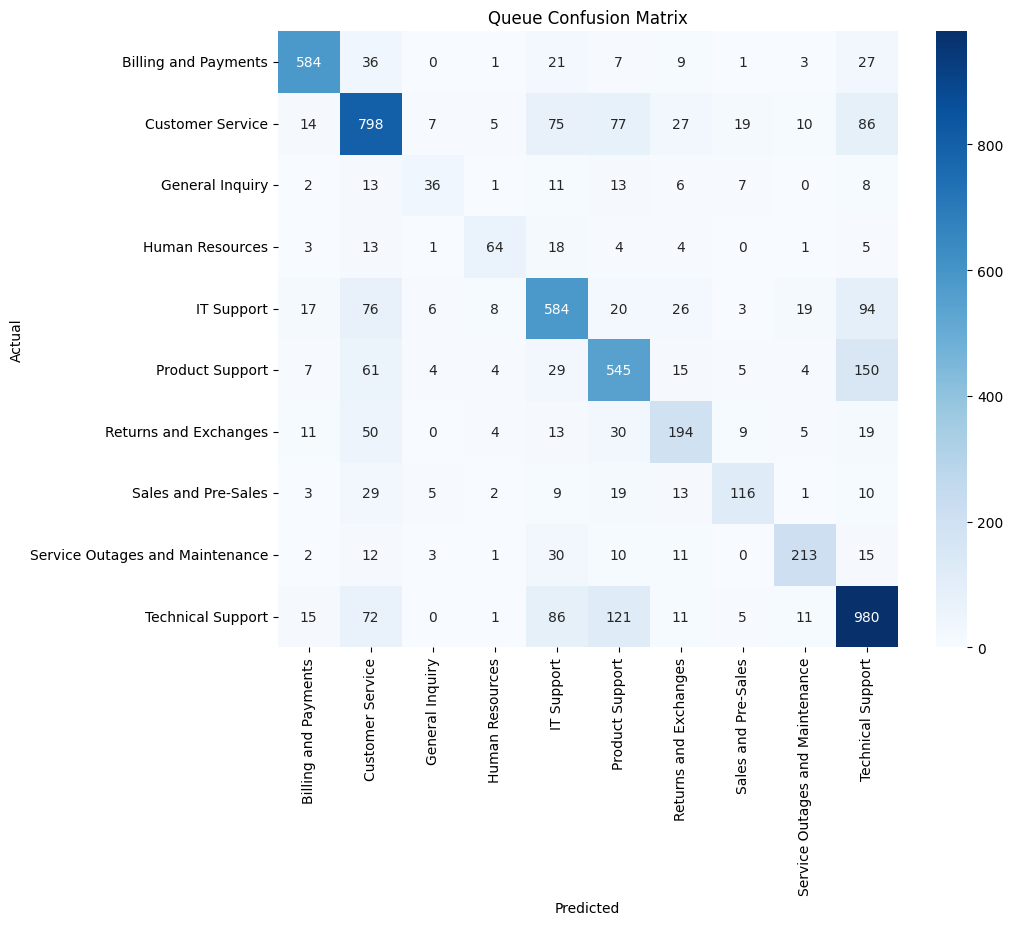

In [67]:
from sklearn.metrics import confusion_matrix
queue_cm = confusion_matrix(queue_true, queue_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    queue_cm,
    annot=True,
    fmt="d",
    xticklabels=queue_encoder.classes_,
    yticklabels=queue_encoder.classes_,
    cmap="Blues"
)
plt.title("Queue Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

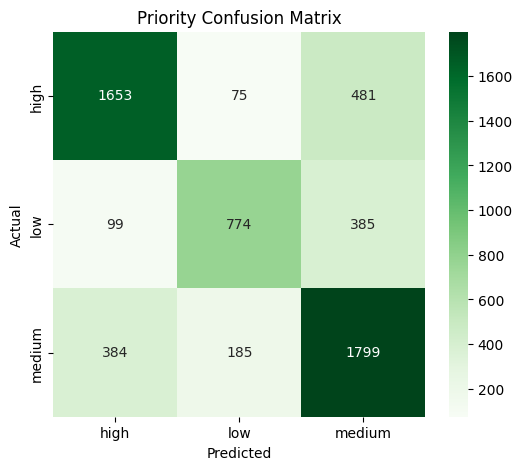

In [68]:
priority_cm = confusion_matrix(priority_true, priority_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    priority_cm,
    annot=True,
    fmt="d",
    xticklabels=priority_encoder.classes_,
    yticklabels=priority_encoder.classes_,
    cmap="Greens"
)
plt.title("Priority Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()